In [1]:
import cv2
import numpy as np
import ultralytics

print("OpenCV :", cv2.__version__)
print("NumPy  :", np.__version__)
print("Ultralytics :", ultralytics.__version__)

print("\n✅ Environnement prêt !")

OpenCV : 4.13.0
NumPy  : 2.3.5
Ultralytics : 8.4.41

✅ Environnement prêt !


In [2]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("✅ Modèle YOLO chargé avec succès")

✅ Modèle YOLO chargé avec succès


In [30]:
import cv2

video_path = "C:/Users/soukaina/Desktop/Stage huile/savons.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("❌ Impossible d'ouvrir la vidéo")
else:
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    duration = frames / fps if fps > 0 else 0

    print("✅ Vidéo ouverte avec succès")
    print("Resolution :", width, "x", height)
    print("FPS :", fps)
    print("Nombre de frames :", frames)
    print("Durée :", round(duration, 2), "secondes")

cap.release()

✅ Vidéo ouverte avec succès
Resolution : 478 x 850
FPS : 29.9768148816581
Nombre de frames : 2098
Durée : 69.99 secondes


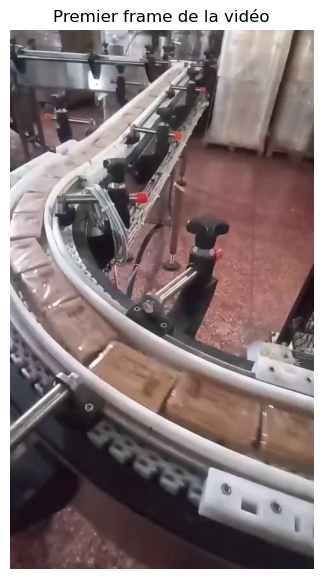

In [29]:
import cv2
import matplotlib.pyplot as plt

video_path = "C:/Users/soukaina/Desktop/Stage huile/savons.mp4"

cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()

cap.release()

if not ret:
    print("❌ Impossible de lire le frame")
else:
# BGR for open cv 
# RGB for matplotlib
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 7))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.title("Premier frame de la vidéo")
    plt.show()

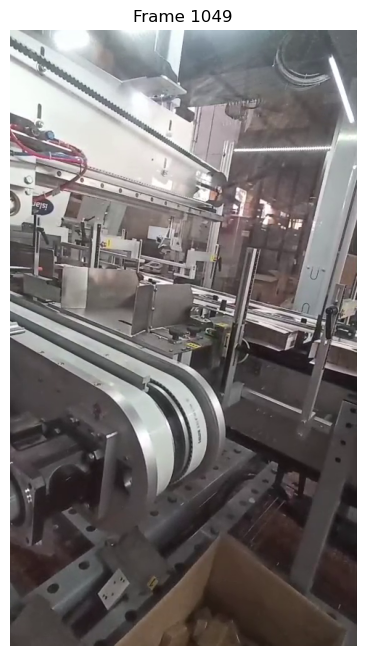

In [31]:
import cv2
import matplotlib.pyplot as plt

video_path = "C:/Users/soukaina/Desktop/Stage huile/savons.mp4"

cap = cv2.VideoCapture(video_path)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
middle_frame = total_frames // 2

cap.set(cv2.CAP_PROP_POS_FRAMES, middle_frame)

ret, frame = cap.read()
cap.release()

if not ret:
    print("❌ Impossible de lire le frame")
else:
    # BGR → RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14, 8))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.title(f"Frame {middle_frame}")
    plt.show()

In [32]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("✅ YOLO chargé")
print(model.names)

✅ YOLO chargé
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone

In [33]:
import cv2
import os

video_path = "C:/Users/soukaina/Desktop/Stage huile/savons.mp4"

output_dir = "dataset/images"
os.makedirs(output_dir, exist_ok=True)

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("FPS :", fps)
print("Total frames :", total_frames)

frame_interval = 30

frame_number = 0
saved_images = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    if frame_number % frame_interval == 0:
        filename = os.path.join(
            output_dir,
            f"savon_{saved_images:04d}.jpg"
        )

        cv2.imwrite(filename, frame)
        saved_images += 1

    frame_number += 1

cap.release()

print("✅ Extraction terminée")
print("Images sauvegardées :", saved_images)

FPS : 29.9768148816581
Total frames : 2098
✅ Extraction terminée
Images sauvegardées : 70


In [34]:
import cv2
import matplotlib.pyplot as plt
import os

image_dir = "dataset/images"

images = sorted(os.listdir(image_dir))

print("Nombre d'images :", len(images))
print("Premières images :", images[:5])

Nombre d'images : 70
Premières images : ['savon_0000.jpg', 'savon_0001.jpg', 'savon_0002.jpg', 'savon_0003.jpg', 'savon_0004.jpg']


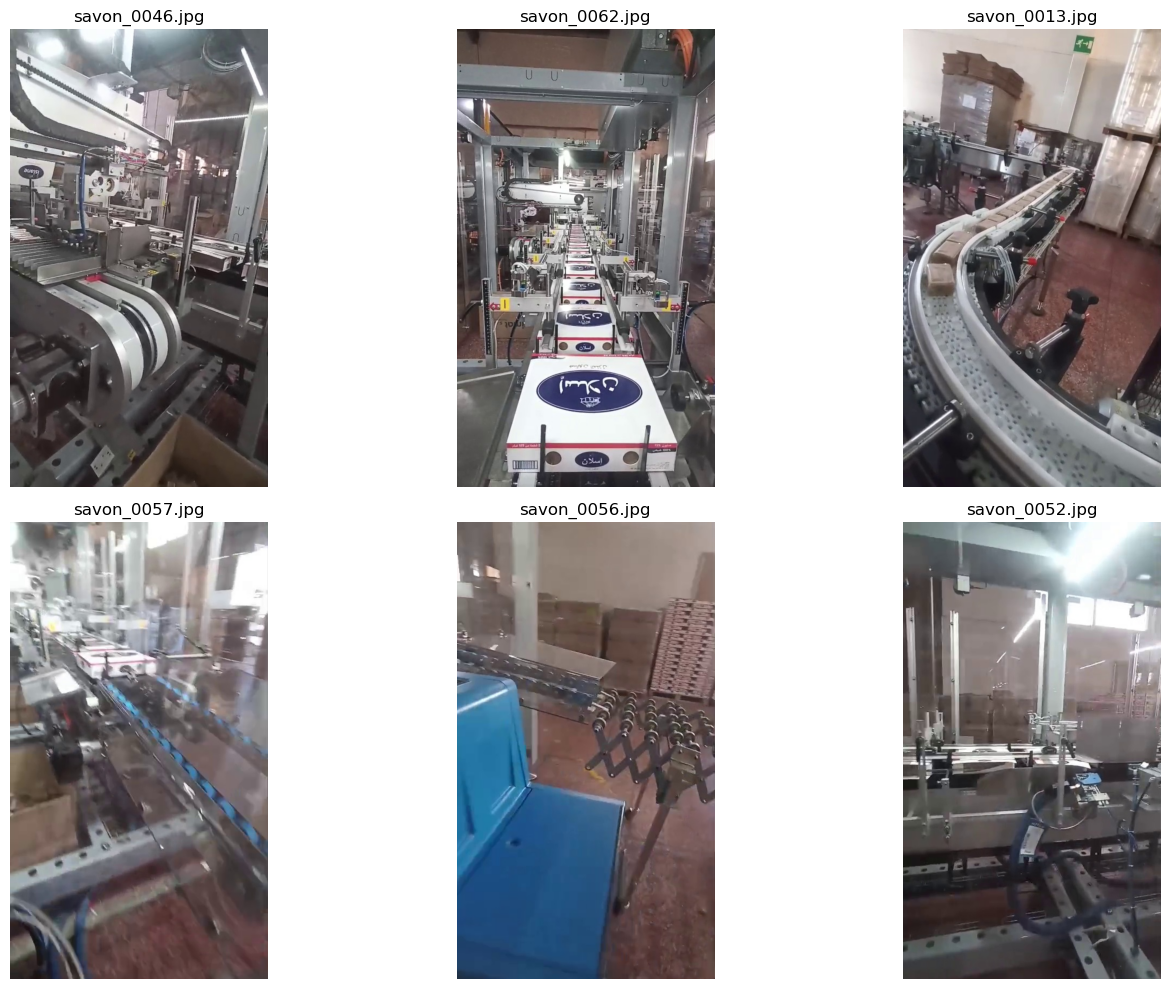

In [35]:
import random

selected_images = random.sample(images, min(6, len(images)))

plt.figure(figsize=(15, 10))

for i, image_name in enumerate(selected_images):
    image_path = os.path.join(image_dir, image_name)

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(image_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [36]:
import os

image_dir = "dataset/images"
images = sorted(os.listdir(image_dir))

print("Nombre total d'images :", len(images))

Nombre total d'images : 70


In [37]:
import cv2
import numpy as np
import os
from pathlib import Path

images_dir = 'dataset/images'
labels_dir = 'dataset/labels'
os.makedirs(labels_dir, exist_ok=True)

for img_file in sorted(os.listdir(images_dir)):
    if img_file.endswith(('.jpg', '.png')):
        img_path = os.path.join(images_dir, img_file)
        img = cv2.imread(img_path)
        h, w = img.shape[:2]
        
        # Convert to HSV (meilleur pour détecter les couleurs)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        
        # Range pour marron/beige (adjust si besoin)
        lower_brown = np.array([10, 50, 50])
        upper_brown = np.array([25, 200, 200])
        
        # Créer mask
        mask = cv2.inRange(hsv, lower_brown, upper_brown)
        
        # Morphological operations
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        
        # Find contours
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # Créer fichier annotations
        txt_file = os.path.join(labels_dir, img_file.replace('.jpg', '.txt').replace('.png', '.txt'))
        
        with open(txt_file, 'w') as f:
            for cnt in contours:
                area = cv2.contourArea(cnt)
                # Filter small noise (savons ont une taille min)
                if area > 500:  # Adjust selon la taille réelle
                    x, y, w_box, h_box = cv2.boundingRect(cnt)
                    
                    # Convert to YOLO format (normalized)
                    cx = (x + w_box/2) / w
                    cy = (y + h_box/2) / h
                    bw = w_box / w
                    bh = h_box / h
                    
                    f.write(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")
        
        print(f"✓ {img_file} - {len([c for c in contours if cv2.contourArea(c) > 500])} boxes")

print("✓ Done!")

✓ savon_0000.jpg - 4 boxes
✓ savon_0001.jpg - 3 boxes
✓ savon_0002.jpg - 5 boxes
✓ savon_0003.jpg - 2 boxes
✓ savon_0004.jpg - 4 boxes
✓ savon_0005.jpg - 4 boxes
✓ savon_0006.jpg - 8 boxes
✓ savon_0007.jpg - 3 boxes
✓ savon_0008.jpg - 4 boxes
✓ savon_0009.jpg - 5 boxes
✓ savon_0010.jpg - 3 boxes
✓ savon_0011.jpg - 2 boxes
✓ savon_0012.jpg - 3 boxes
✓ savon_0013.jpg - 4 boxes
✓ savon_0014.jpg - 3 boxes
✓ savon_0015.jpg - 5 boxes
✓ savon_0016.jpg - 4 boxes
✓ savon_0017.jpg - 1 boxes
✓ savon_0018.jpg - 3 boxes
✓ savon_0019.jpg - 1 boxes
✓ savon_0020.jpg - 3 boxes
✓ savon_0021.jpg - 5 boxes
✓ savon_0022.jpg - 4 boxes
✓ savon_0023.jpg - 2 boxes
✓ savon_0024.jpg - 3 boxes
✓ savon_0025.jpg - 4 boxes
✓ savon_0026.jpg - 5 boxes
✓ savon_0027.jpg - 1 boxes
✓ savon_0028.jpg - 2 boxes
✓ savon_0029.jpg - 1 boxes
✓ savon_0030.jpg - 2 boxes
✓ savon_0031.jpg - 2 boxes
✓ savon_0032.jpg - 3 boxes
✓ savon_0033.jpg - 1 boxes
✓ savon_0034.jpg - 1 boxes
✓ savon_0035.jpg - 1 boxes
✓ savon_0036.jpg - 1 boxes
✓

In [39]:
import cv2
import numpy as np
import os
import yaml
import pandas as pd
from pathlib import Path
from collections import defaultdict
from ultralytics import YOLO
import warnings
warnings.filterwarnings('ignore')

print("✅ Tous les imports OK!")

✅ Tous les imports OK!


In [41]:
# À ADAPTER SELON TON CHEMIN!
DATASET_ROOT = "dataset"  # Dossier avec images/ et labels/
VIDEO_PATH = "video.mp4"   # Ta vidéo
OUTPUT_DIR = "results"
MODEL_PATH = "runs/detect/savon_detector/weights/best.pt"
COUNTING_LINE_X = 0.85  # 85% à droite (sortie)

# Créer dossiers
Path(OUTPUT_DIR).mkdir(exist_ok=True)
Path(f"{DATASET_ROOT}/labels").mkdir(parents=True, exist_ok=True)

print(f"✅ Config:")
print(f"   Dataset: {DATASET_ROOT}")
print(f"   Vidéo: {VIDEO_PATH}")
print(f"   Output: {OUTPUT_DIR}")

✅ Config:
   Dataset: dataset
   Vidéo: video.mp4
   Output: results


In [42]:
def detect_savons_color(img_path):
    """Détecte savons par plage couleur HSV"""
    img = cv2.imread(img_path)
    if img is None:
        return []
    
    h, w = img.shape[:2]
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Range pour savons marron/beige (AJUSTER si besoin!)
    lower_brown = np.array([10, 60, 50])
    upper_brown = np.array([25, 255, 200])
    
    mask = cv2.inRange(hsv, lower_brown, upper_brown)
    
    # Morphologie
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
    
    # Contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    boxes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if 300 < area < 50000:
            x, y, bw, bh = cv2.boundingRect(cnt)
            if bw > 0 and bh > 0:
                ratio = max(bw, bh) / min(bw, bh)
                if ratio < 5:
                    boxes.append((x, y, x + bw, y + bh))
    
    return boxes

def boxes_to_yolo(boxes, img_width, img_height):
    """Convertit boxes en format YOLO"""
    yolo_lines = []
    for x1, y1, x2, y2 in boxes:
        cx = ((x1 + x2) / 2) / img_width
        cy = ((y1 + y2) / 2) / img_height
        bw = (x2 - x1) / img_width
        bh = (y2 - y1) / img_height
        yolo_lines.append(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
    return yolo_lines

print("✅ Fonctions auto-annotation OK!")

✅ Fonctions auto-annotation OK!


In [43]:
# AUTO-ANNOTATION
images_dir = os.path.join(DATASET_ROOT, "images")
labels_dir = os.path.join(DATASET_ROOT, "labels")

image_files = sorted([f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
print(f"🔍 {len(image_files)} images trouvées\n")

total_boxes = 0
for img_file in image_files:
    img_path = os.path.join(images_dir, img_file)
    
    # Détection
    boxes = detect_savons_color(img_path)
    
    # Conversion YOLO
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    yolo_lines = boxes_to_yolo(boxes, w, h)
    
    # Écrire fichier .txt
    txt_filename = img_file.rsplit('.', 1)[0] + '.txt'
    txt_path = os.path.join(labels_dir, txt_filename)
    
    with open(txt_path, 'w') as f:
        for line in yolo_lines:
            f.write(line + '\n')
    
    total_boxes += len(boxes)
    status = "✓" if len(boxes) > 0 else "⚠️"
    if len(image_files) <= 10 or len(image_files) % 7 == 0:
        print(f"{status} {img_file}: {len(boxes)} box(es)")

print(f"\n✅ Auto-annotation terminée!")
print(f"   Total boxes: {total_boxes}")
print(f"   Moyenne par image: {total_boxes/len(image_files):.1f}")

🔍 70 images trouvées

✓ savon_0000.jpg: 3 box(es)
✓ savon_0001.jpg: 3 box(es)
✓ savon_0002.jpg: 3 box(es)
✓ savon_0003.jpg: 2 box(es)
✓ savon_0004.jpg: 2 box(es)
✓ savon_0005.jpg: 3 box(es)
✓ savon_0006.jpg: 2 box(es)
⚠️ savon_0007.jpg: 0 box(es)
✓ savon_0008.jpg: 1 box(es)
✓ savon_0009.jpg: 3 box(es)
✓ savon_0010.jpg: 2 box(es)
✓ savon_0011.jpg: 3 box(es)
✓ savon_0012.jpg: 2 box(es)
✓ savon_0013.jpg: 1 box(es)
✓ savon_0014.jpg: 2 box(es)
✓ savon_0015.jpg: 3 box(es)
✓ savon_0016.jpg: 3 box(es)
✓ savon_0017.jpg: 2 box(es)
✓ savon_0018.jpg: 1 box(es)
⚠️ savon_0019.jpg: 0 box(es)
✓ savon_0020.jpg: 1 box(es)
✓ savon_0021.jpg: 3 box(es)
✓ savon_0022.jpg: 2 box(es)
✓ savon_0023.jpg: 1 box(es)
⚠️ savon_0024.jpg: 0 box(es)
✓ savon_0025.jpg: 1 box(es)
✓ savon_0026.jpg: 3 box(es)
⚠️ savon_0027.jpg: 0 box(es)
✓ savon_0028.jpg: 2 box(es)
✓ savon_0029.jpg: 1 box(es)
✓ savon_0030.jpg: 3 box(es)
✓ savon_0031.jpg: 4 box(es)
✓ savon_0032.jpg: 4 box(es)
✓ savon_0033.jpg: 1 box(es)
✓ savon_0034.jpg: 1 bo

In [40]:
import os

# Chemin
DATASET_ROOT = r"C:\Users\soukaina\anaconda_projects\db\dataset"

# ✅ CRÉER DOSSIER S'IL N'EXISTE PAS
os.makedirs(DATASET_ROOT, exist_ok=True)

print(f"✅ Dossier créé/existe: {DATASET_ROOT}")

# Créer data.yaml
import yaml

data_yaml = {
    'path': os.path.abspath(DATASET_ROOT),
    'train': 'images',
    'val': 'images',
    'nc': 1,
    'names': ['savon']
}

yaml_path = os.path.join(DATASET_ROOT, 'data.yaml')

with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

print(f"✅ data.yaml créé: {yaml_path}")

# Vérifier
if os.path.exists(yaml_path):
    print(f"✅ Fichier vérifié!")
    with open(yaml_path, 'r') as f:
        print(f"\n📋 Contenu:\n{f.read()}")

✅ Dossier créé/existe: C:\Users\soukaina\anaconda_projects\db\dataset
✅ data.yaml créé: C:\Users\soukaina\anaconda_projects\db\dataset\data.yaml
✅ Fichier vérifié!

📋 Contenu:
names:
- savon
nc: 1
path: C:\Users\soukaina\anaconda_projects\db\dataset
train: images
val: images



In [41]:
import os
import yaml

DATASET_ROOT = r"C:\Users\soukaina\anaconda_projects\db\dataset"  # ✅ VRAI CHEMIN

data_yaml = {
    'path': os.path.abspath(DATASET_ROOT),
    'train': 'images',
    'val': 'images',
    'nc': 1,
    'names': ['savon']
}

yaml_path = os.path.join(DATASET_ROOT, 'data.yaml')

with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

print(f"✅ data.yaml créé: {yaml_path}")

✅ data.yaml créé: C:\Users\soukaina\anaconda_projects\db\dataset\data.yaml


In [42]:
# Créer data.yaml pour YOLO
data_yaml = {
    'path': os.path.abspath(DATASET_ROOT),
    'train': 'images',
    'val': 'images',
    'nc': 1,  # 1 classe: savon
    'names': ['savon']
}

yaml_path = os.path.join(DATASET_ROOT, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

print(f"✅ data.yaml créé: {yaml_path}")
print(f"   Path: {data_yaml['path']}")
print(f"   Classes: {data_yaml['names']}")

✅ data.yaml créé: C:\Users\soukaina\anaconda_projects\db\dataset\data.yaml
   Path: C:\Users\soukaina\anaconda_projects\db\dataset
   Classes: ['savon']


In [49]:
import os

images_path = r"C:\Users\soukaina\Desktop\Stage huile\anaconda_projects\db\dataset\images"
labels_path = r"C:\Users\soukaina\anaconda_projects\db\dataset\labels"

# Vérifier images
images = [f for f in os.listdir(images_path) if f.endswith(('.jpg', '.png'))]
print(f"✅ Images trouvées: {len(images)}")

# Vérifier labels
if os.path.exists(labels_path):
    labels = [f for f in os.listdir(labels_path) if f.endswith('.txt')]
    print(f"✅ Labels trouvés: {len(labels)}")
    if len(labels) == 0:
        print(f"❌ PROBLÈME: Pas de fichiers .txt!")
else:
    print(f"❌ Dossier labels n'existe pas!")
    os.makedirs(labels_path, exist_ok=True)
    print(f"✅ Dossier labels créé")

✅ Images trouvées: 70
❌ Dossier labels n'existe pas!
✅ Dossier labels créé


In [50]:
import os

# ✅ BON CHEMIN (avec "Stage huile" et "Desktop")
images_path = r"C:\Users\soukaina\Desktop\Stage huile\anaconda_projects\db\dataset\images"
labels_path = r"C:\Users\soukaina\Desktop\Stage huile\anaconda_projects\db\dataset\labels"

# Vérifier
if os.path.exists(images_path):
    images = [f for f in os.listdir(images_path) if f.endswith(('.jpg', '.png'))]
    print(f"✅ Images trouvées: {len(images)}")
else:
    print(f"❌ Chemin introuvable: {images_path}")

✅ Images trouvées: 70


In [1]:
class SimpleTracker:
    def __init__(self, max_age=30):
        self.tracks = {}
        self.next_id = 0
        self.max_age = max_age
        self.frame_count = 0
        
    def update(self, detections):
        self.frame_count += 1
        
        # Centroïdes des détections
        centroids = []
        for det in detections:
            x1, y1, x2, y2 = det[:4]
            cx = (x1 + x2) / 2
            cy = (y1 + y2) / 2
            centroids.append((cx, cy, det))
        
        # Matching
        matched_ids = {}
        for track_id, track_data in self.tracks.items():
            if track_data['age'] > self.max_age:
                continue
            
            best_dist = float('inf')
            best_idx = -1
            
            for idx, (cx, cy, det) in enumerate(centroids):
                if idx in matched_ids:
                    continue
                
                dist = np.sqrt((cx - track_data['cx'])**2 + (cy - track_data['cy'])**2)
                if dist < best_dist and dist < 50:
                    best_dist = dist
                    best_idx = idx
            
            if best_idx >= 0:
                matched_ids[best_idx] = track_id
                cx, cy, det = centroids[best_idx]
                self.tracks[track_id]['cx'] = cx
                self.tracks[track_id]['cy'] = cy
                self.tracks[track_id]['det'] = det
                self.tracks[track_id]['age'] = 0
        
        # Results
        results = []
        for track_id, track_data in self.tracks.items():
            if track_data['age'] <= self.max_age:
                det = track_data['det']
                results.append((*det[:4], track_id))
        
        # Nouvelles tracks
        for idx, (cx, cy, det) in enumerate(centroids):
            if idx not in matched_ids:
                self.tracks[self.next_id] = {'cx': cx, 'cy': cy, 'det': det, 'age': 0}
                results.append((*det[:4], self.next_id))
                self.next_id += 1
        
        # Age
        for track_id in self.tracks:
            self.tracks[track_id]['age'] += 1
        
        return results

print("✅ Classe Tracker OK!")

✅ Classe Tracker OK!


In [2]:
class AnomalyDetector:
    def __init__(self):
        self.anomalies = defaultdict(list)
    
    def check_packaging_damaged(self, crop, threshold=0.3):
        """Packaging déchiré - variation texture"""
        gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        variance = laplacian.var()
        return variance > threshold * 1000
    
    def check_triangle_shape(self, crop):
        """Pas triangle - analyse contours"""
        gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        _, binary = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if not contours:
            return False
        
        cnt = max(contours, key=cv2.contourArea)
        epsilon = 0.02 * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        
        # Triangle = 3 points
        return 2 <= len(approx) <= 4
    
    def check_alignment(self, crop, savon_mask, threshold=0.6):
        """Mal aligné - centrage dans box"""
        h, w = crop.shape[:2]
        moments = cv2.moments(savon_mask)
        
        if moments['m00'] == 0:
            return False
        
        cx = moments['m10'] / moments['m00']
        cy = moments['m01'] / moments['m00']
        center_x, center_y = w / 2, h / 2
        
        dist = np.sqrt((cx - center_x)**2 + (cy - center_y)**2)
        max_dist = (w + h) / 4 * threshold
        
        return dist < max_dist
    
    def check_packaging_present(self, crop, threshold=0.1):
        """Packaging absent - détecte pixels clairs"""
        gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        white_pixels = np.sum(gray > 200) / gray.size
        return white_pixels > threshold

print("✅ Classe AnomalyDetector OK!")

✅ Classe AnomalyDetector OK!
